# Generate Paper Figures

**Step 5 of 5 — regenerates the paper's figures.** Consumes results from notebooks 02-03 (and archived reference data for Figure 4); produces `notebooks/figures/{pulp_benders_gaps,pulp_benders_times,julia_benders_toy_gaps,toy_0_vrp_solution,solution_frequencies_by_cost}.pdf`.

Figure sourcing:
- **Figures 1 & 2** (`pulp_benders_gaps.pdf`, `pulp_benders_times.pdf`) load fresh results from `experimental-data/results/qoptlib-mcms/` (produced by notebook 02).
- **Figure 3** (`julia_benders_toy_gaps.pdf`) loads fresh results from `experimental-data/results/toy-hqc-mcms/` (produced by notebook 03), plus a VRP solution plot.
- **Figure 4** (`solution_frequencies_by_cost.pdf`) combines archived MPS-JuliQAOA results from `experimental-data/archived/julia-qaoa/` and archived Fermioniq/IBM-hardware baseline from `experimental-data/archived/fermioniq-ibm/` (these predate this paper and cannot be regenerated).

If result files are missing, the relevant figure cell will raise `FileNotFoundError` telling you which upstream notebook to run.

## Setup

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

# Paths
repo_path = Path("")
experimental_data_dir = repo_path / "experimental-data"
results_dir = experimental_data_dir / "results"
instances_dir = experimental_data_dir / "instances"
archived_dir = experimental_data_dir / "archived"
figures_dir = repo_path / "notebooks" / "figures"
(figures_dir / "archive").mkdir(parents=True, exist_ok=True)

# Plotting config
markers = ["o", "s", "^", "D", "x", "v", "<", ">", "p", "*"]
plt.style.use("seaborn-v0_8-whitegrid")

# Colormap
cmap_dark2 = plt.get_cmap("Dark2")
cmap = lambda x: cmap_dark2.colors

print("Setup complete.")

Setup complete.


## Helper Functions

In [2]:
def load_experiment_results(result_folder):
    """Load iterations.jsonl from a result folder."""
    iterations_file = result_folder / "iterations.jsonl"
    if not iterations_file.exists():
        raise FileNotFoundError(
            f"iterations.jsonl not found in {result_folder}"
        )

    iterations = []
    with open(iterations_file) as f:
        for line in f:
            iterations.append(json.loads(line))

    return iterations


def moving_average(arr, window):
    return np.convolve(
        np.nanmean(arr, axis=0), np.ones(window) / window, mode="valid"
    )


def moving_percentile(arr, window, percentile=50):
    return np.convolve(
        np.nanpercentile(arr, percentile, axis=0),
        np.ones(window) / window,
        mode="valid",
    )


print("Helper functions defined.")

Helper functions defined.


# Figures 1 & 2: QOptLib Classical MCMS Experiments

## Load QOptLib Results

In [3]:
# Discover result folders from notebook 02
qoptlib_results_dir = results_dir / "qoptlib-mcms"

# Or use archived data
qoptlib_results_dir = archived_dir / "qoptlib-mcms"

if not qoptlib_results_dir.exists():
    raise FileNotFoundError(
        f"{qoptlib_results_dir} not found. Please run notebook 02 first."
    )

# Result folders are named: {instance}_n{n_subproblems}
result_folders = sorted(qoptlib_results_dir.glob("*_n*"))
print(f"Found {len(result_folders)} QOptLib result folders.\n")

# Parse and group by n_subproblems
qoptlib_results = {}
for folder in result_folders:
    # Extract instance name and n_subproblems from folder name
    folder_name = folder.name
    # Expected format: XSH-n20-k4-01_perm{i}_n{n}
    parts = folder_name.rsplit("_n", 1)
    if len(parts) != 2:
        print(f"Skipping unexpected folder name: {folder_name}")
        continue
    instance_name = parts[0]
    n_subproblems = int(parts[1])

    iterations = load_experiment_results(folder)

    key = (instance_name, n_subproblems)
    qoptlib_results[key] = iterations

# Group by n_subproblems for plotting
n_subproblems_values = sorted(set(k[1] for k in qoptlib_results.keys()))
print(f"n_subproblems values: {n_subproblems_values}")
print(f"Total experiments: {len(qoptlib_results)}")

Found 40 QOptLib result folders.

n_subproblems values: [2, 4, 16, 64]
Total experiments: 40


## Figure 1: Optimality Gaps

* The more sub problems you consider, the earlier (in terms of number of iterations) you find bounds and the lower the gap in iterations (i.e. the lines never cross).
* Different cut-off's because limits were 'time', not 'number of iterations'
* This means that using more sub problems yields results 'faster' (in terms of iterations)

In [4]:
# Extract gaps grouped by n_subproblems
gaps_grouped = {n: [] for n in n_subproblems_values}
for (instance_name, n_subproblems), iterations in qoptlib_results.items():
    ubs = [it["upper_bound"] for it in iterations]
    lbs = [it["lower_bound"] for it in iterations]
    gaps = [
        (
            (ub - lb) / ub
            if not (np.isnan(ub) or np.isnan(lb) or lb < 0 or ub <= 0)
            else np.nan
        )
        for ub, lb in zip(ubs, lbs)
    ]
    gaps_grouped[n_subproblems].append(gaps)

/var/folders/bs/5gjxly651bxd3ny3rw7r4qzr0000gn/T/ipykernel_23805/103829226.py:19: RuntimeWarning: Mean of empty slice
  np.nanmean(arr, axis=0), np.ones(window) / window, mode="valid"


Saving figure to notebooks/figures/pulp_benders_gaps.pdf


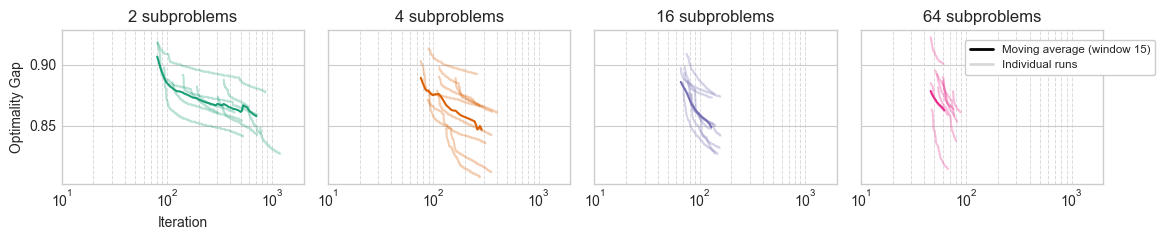

In [5]:
import time

from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 4, figsize=(12, 2.5), sharex=True, sharey=True)
axes = axes.flatten()

window_size = 15  # You can adjust the window size for the moving average

colors = cmap_dark2.colors

for idx, n in enumerate(n_subproblems_values):
    gaps_list = gaps_grouped[n]
    med_len = int(np.median([len(gaps) for gaps in gaps_list]))
    gaps_list_padded = [
        (
            gaps + [np.nan] * (med_len - len(gaps))
            if len(gaps) < med_len
            else gaps[:med_len]
        )
        for gaps in gaps_list
    ]
    gaps_array = np.array(gaps_list_padded)
    # Compute moving average mean, ignoring NaNs

    ma_mean_gaps = moving_average(gaps_array, window_size)
    ax = axes[idx]
    ax.plot(
        np.arange(len(ma_mean_gaps)),
        ma_mean_gaps,
        label=f"n_subproblems={n}",
        color=colors[idx],
    )
    # Plot individual runs (not moving average) with faded colors
    for gaps in gaps_list:
        ax.plot(np.arange(len(gaps)), gaps, color=colors[idx], alpha=0.3)
    ax.set_title(f"{n} subproblems")
    ax.set_xscale("log")
    ax.set_xlim(10, 2000)
    ax.grid(
        True, which="both", axis="x", linestyle="--", linewidth=0.7, alpha=0.7
    )  # Show grid lines for log scale
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Optimality Gap")

# Add custom legend handles for moving average and individual runs
labels = [f"Moving average (window {window_size})", "Individual runs"]
handles = [
    Line2D([0], [0], color="black", lw=2, label=labels[0]),
    Line2D([0], [0], color="grey", lw=2, alpha=0.3, label=labels[1]),
]
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.81, 0.75),
    fontsize="small",
    frameon=True,
    framealpha=1,
    facecolor="white",
)

plt.tight_layout()
fig.subplots_adjust(right=0.93)
fig_name = f"pulp_benders_gaps.pdf"
print(f"Saving figure to {figures_dir / fig_name}")
plt.savefig(figures_dir / fig_name, dpi=300)
# also save with timestamp in figures_dir/"archive" for versioning
plt.savefig(
    figures_dir / "archive" / f"pulp_benders_gaps_{int(time.time())}.pdf",
    dpi=300,
)

## Figure 2: Solve Times

* This strengthens Paterakis's conclusion: doing large number of sub problems is valuable, however, large cut selection is expensive
* Then, the question arises "okay, yes, but it this cut selection really the issue". Then show timing spent on MP solving, parallel SP solving, cut selection solving per iteration (Figure \ref{fig:timing-in-iterations})
* Majority is spent on MP solving
* SP solving stays constant over iterations
* Cut selection is easy $\leftarrow$ \textbf{This is important for our discussion!!}

In [6]:
# Plot the average times spent on each component per iteration, grouped by number of subproblems

times = [
    "sp_solving_time",
    "mp_solving_time",
    "cut_selection_time",
    "iteration_time",
]
times_labels = {
    "sp_solving_time": "SP Solving Time",
    "mp_solving_time": "MP Solving Time",
    "cut_selection_time": "Cut Selection Time",
    "iteration_time": "Total Iteration Time",
}

# Extract times
times_grouped = {n: {time: [] for time in times} for n in n_subproblems_values}
for (instance_name, n_subproblems), iterations in qoptlib_results.items():
    for timing in times:
        time_values = [it["runtimes"][timing] for it in iterations]
        times_grouped[n_subproblems][timing].append(time_values)

Saving figure to notebooks/figures/pulp_benders_times.pdf


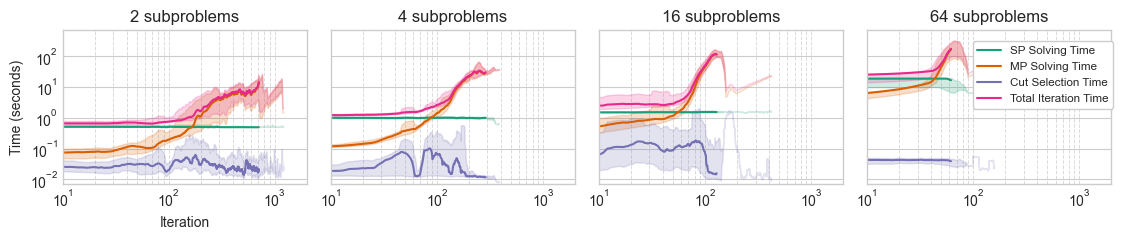

In [7]:
# Plotting
fig, axes = plt.subplots(1, 4, figsize=(12, 2.5), sharex=True, sharey=True)
colors = cmap_dark2.colors
colors_time = {timing: colors[idx] for idx, timing in enumerate(times)}

for idx, n in enumerate(n_subproblems_values):
    ax = axes[idx]
    for timing in times:
        time_list = times_grouped[n][timing]
        med_len = int(np.median([len(t) for t in time_list]))
        time_list_padded = [
            (
                t + [np.nan] * (med_len - len(t))
                if len(t) < med_len
                else t[:med_len]
            )
            for t in time_list
        ]
        max_len = max(len(t) for t in time_list)
        time_list_right_padded = [
            t + [np.nan] * (max_len - len(t)) for t in time_list
        ]
        time_array = np.array(time_list_padded)
        ma_median_time = moving_percentile(
            time_array, window_size, percentile=50
        )
        ax.plot(
            np.arange(len(ma_median_time)),
            ma_median_time,
            label=times_labels[timing],
            color=colors_time[timing],
        )
        # Also plot shaded regions for percentiles (also smoothed)
        # Compute percentiles, ignoring NaNs
        time_array_right_padded = np.array(time_list_right_padded)
        ma_perc_25 = moving_percentile(
            time_array_right_padded, window_size, percentile=25
        )
        ma_perc_75 = moving_percentile(
            time_array_right_padded, window_size, percentile=75
        )
        ax.fill_between(
            np.arange(len(ma_perc_25)),
            ma_perc_25,
            ma_perc_75,
            color=colors_time[timing],
            alpha=0.2,
        )

    ax.set_title(f"{n} subproblems")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlim(10, 2000)
    ax.set_ylim(0.007, 700)
    ax.grid(
        True, which="both", axis="x", linestyle="--", linewidth=0.7, alpha=0.7
    )  # Show grid lines for log scale
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Time (seconds)")
# axes[-1].legend(
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5),
#     fontsize="small",
#     frameon=True,
#     framealpha=1,
#     facecolor="white")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.81, 0.68),
    fontsize="small",
    frameon=True,
    framealpha=1,
    facecolor="white",
)

plt.tight_layout()
plt.subplots_adjust(right=0.93)
fig_name = f"pulp_benders_times.pdf"
print(f"Saving figure to {figures_dir / fig_name}")
plt.savefig(figures_dir / fig_name, dpi=300)
# also save with timestamp in figures_dir/"archive" for versioning
plt.savefig(
    figures_dir / "archive" / f"pulp_benders_times_{int(time.time())}.pdf",
    dpi=300,
)

# Figure 3: Toy HQC-MCMS Experiments with Julia QAOA

## Load Toy Results

In [8]:
# Discover result folders from notebook 03
toy_results_dir = results_dir / "toy-hqc-mcms"

# Or use archived data
toy_results_dir = archived_dir / "toy-hqc-mcms"
if not toy_results_dir.exists():
    raise FileNotFoundError(
        f"{toy_results_dir} not found. Please run notebook 03 first."
    )

# Result folders are named: toy_{i}_p{depth}
result_folders = sorted(toy_results_dir.glob("toy_*_p*"))
print(f"Found {len(result_folders)} toy result folders.\n")

# Parse and load
toy_results = {}
for folder in result_folders:
    folder_name = folder.name
    # Expected format: toy_{i}_p{depth}
    parts = folder_name.rsplit("_p", 1)
    if len(parts) != 2:
        print(f"Skipping unexpected folder name: {folder_name}")
        continue
    instance_name = parts[0]
    qaoa_depth = int(parts[1])

    iterations = load_experiment_results(folder)

    key = (instance_name, qaoa_depth)
    toy_results[key] = {"iterations": iterations, "folder": folder}

print(f"Total toy experiments: {len(toy_results)}")

Found 5 toy result folders.

Total toy experiments: 5


## Plot VRP Solution Helper

In [9]:
import pulp


def plot_vrp_solution(
    prob,
    vrp,
    figures_dir,
    label="toy",
    plot_title="VRP Instance with Solution Routes",
    ax=None,
    legend=True,
    annotate_nodes=True,
    size_multiplier=1.0,
):
    colors_local = cmap_dark2.colors

    if prob.status != pulp.LpStatusOptimal:
        print(
            f"Warning: Problem status is {pulp.LpStatus[prob.status]}, solving..."
        )
        prob.solve()

    coords = np.array(vrp["coordinates"])

    # Extract active arcs
    active_arcs = []
    for v in prob.variables():
        if (
            v.name.startswith("x_")
            and v.varValue is not None
            and v.varValue > 0.5
        ):
            _, i, j = v.name.split("_")
            active_arcs.append((int(i), int(j)))

    # Build successor dictionary
    successor = {i: j for i, j in active_arcs}

    # Reconstruct routes starting from depot
    routes = []
    for i, j in active_arcs:
        if i == 0:  # route starts at depot
            route = [0, j]
            current = j
            while current != 0:
                current = successor[current]
                route.append(current)
            routes.append(route)

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.scatter(
        coords[0, 0],
        coords[0, 1],
        c=colors_local[0],
        label="Depot",
        s=140 * size_multiplier,
        zorder=3,
        marker="s",
    )
    ax.scatter(
        coords[1:, 0],
        coords[1:, 1],
        c=colors_local[1],
        label="Customers",
        s=100 * size_multiplier,
        zorder=3,
    )

    # Label nodes
    if annotate_nodes:
        for idx, (x, y) in enumerate(coords):
            ax.text(x - 0.2, y + 0.15, str(idx), fontsize=10)

    for r, route in enumerate(routes):
        color = colors_local[r + 2]  # +2 to skip depot and customers colors
        for k in range(len(route) - 1):
            i, j = route[k], route[k + 1]
            x1, y1 = coords[i]
            x2, y2 = coords[j]

            ax.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=2,
                    shrinkA=8,
                    shrinkB=8,
                    alpha=0.8,
                ),
                zorder=2,
            )

        ax.plot([], [], color=color, lw=2, label=f"Route {r+1}")

    ax.set_title(plot_title)
    ax.axis("off")
    if legend:
        ax.legend()
    ax.axis("equal")
    plt.tight_layout()

    return ax


print("VRP solution plotting helper defined.")

VRP solution plotting helper defined.


## Plot Toy Instance with Solution

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/camilledevalk/repositories/logistiqs-ieee-open-code/.venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/bs/5gjxly651bxd3ny3rw7r4qzr0000gn/T/192677b5b78c4919b8dfac6706fbd3ba-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/bs/5gjxly651bxd3ny3rw7r4qzr0000gn/T/192677b5b78c4919b8dfac6706fbd3ba-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 47 COLUMNS
At line 266 RHS
At line 309 BOUNDS
At line 345 ENDATA
Problem MODEL has 42 rows, 35 columns and 130 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 14.7263 - 0.00 seconds
Cgl0003I 2 fixed, 0 tightened bounds, 12 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 10 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 2 strengthened row

/var/folders/bs/5gjxly651bxd3ny3rw7r4qzr0000gn/T/ipykernel_23805/1868241237.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(
/var/folders/bs/5gjxly651bxd3ny3rw7r4qzr0000gn/T/ipykernel_23805/1868241237.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


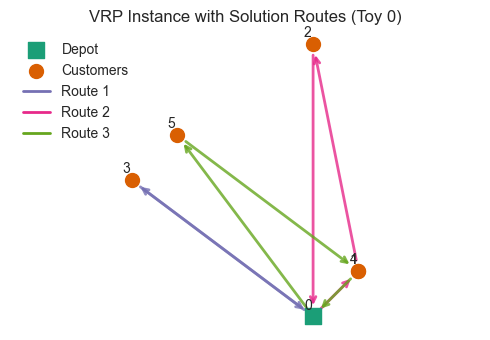

In [10]:
# Load a toy instance and solve it to plot the VRP solution
selected_toy_idx = 0
toy_instance_path = instances_dir / "toy" / f"toy_{selected_toy_idx}.mps"
toy_json_path = instances_dir / "toy" / f"toy_{selected_toy_idx}.json"

if not toy_instance_path.exists():
    raise FileNotFoundError(
        f"{toy_instance_path} not found. Please run notebook 01 first."
    )

prob_vars, prob = pulp.LpProblem.fromMPS(str(toy_instance_path))
vrp = json.loads(toy_json_path.read_text())

plot_vrp_solution(
    prob,
    vrp,
    figures_dir,
    label=f"toy_{selected_toy_idx}",
    plot_title=f"VRP Instance with Solution Routes (Toy {selected_toy_idx})",
)

fig_name = f"toy_{selected_toy_idx}_vrp_solution.pdf"
print(f"Saving figure to {figures_dir / fig_name}")
plt.savefig(figures_dir / fig_name, dpi=300, bbox_inches="tight")
plt.savefig(
    figures_dir
    / "archive"
    / f"toy_{selected_toy_idx}_vrp_solution_{int(time.time())}.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Figure 3: Gaps for Toy Problems

Saving figure to notebooks/figures/julia_benders_toy_gaps.pdf


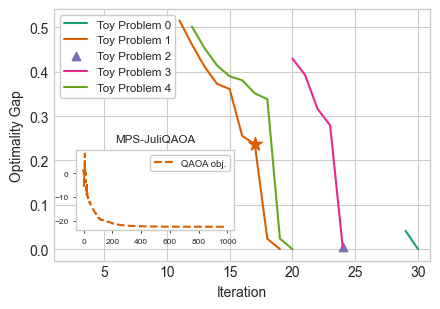

In [11]:
# Filter for QAOA depth p=1 (or choose p=3)
qaoa_depth_filter = 1
toy_results_filtered = {
    k: v for k, v in toy_results.items() if k[1] == qaoa_depth_filter
}

colors_toy = cmap_dark2.colors

# Select QAOA iteration for inset
selected_toy = "toy_1"
selected_iter = 16

# Plot
fig, ax = plt.subplots(figsize=(4.5, 3.2))
axins = ax.inset_axes([0.06, 0.12, 0.42, 0.32])

instance_to_label = lambda x: f"Toy Problem {x.split('_')[-1]}"

for i, ((instance_name, qaoa_depth), result_data) in enumerate(
    toy_results_filtered.items()
):
    iterations = result_data["iterations"]
    label = instance_to_label(instance_name)
    color = colors_toy[i % len(colors_toy)]

    x = [it["iteration"] for it in iterations]
    ubs = [it["upper_bound"] for it in iterations]
    lbs = [it["lower_bound"] for it in iterations]

    gaps = [
        (
            (ub - lb) / ub
            if not (np.isnan(ub) or np.isnan(lb) or lb < 0 or ub <= 0)
            else np.nan
        )
        for ub, lb in zip(ubs, lbs)
    ]

    if np.sum(~np.isnan(gaps), axis=0) > 1:
        ax.plot(x, gaps, alpha=1, label=label, color=color)
    else:
        ax.scatter(
            x,
            gaps,
            alpha=1,
            label=label,
            marker=markers[i % len(markers)],
            color=color,
        )

    # Add to inset if this is the selected toy problem
    if selected_toy in instance_name:
        qaoa_file = result_data["folder"] / f"qaoa_output_{selected_iter}.json"
        if qaoa_file.exists():
            qaoa_output = json.loads(qaoa_file.read_text())
            convergence_trace = [
                it["value"] for it in qaoa_output["optimization_trace"]
            ]
            axins.plot(
                np.arange(len(convergence_trace)),
                convergence_trace,
                label=f"QAOA obj.",
                color=color,
                linestyle="--",
            )
            selected_point = (x[selected_iter], gaps[selected_iter], color)

ax.set_xlim(1, None)
ax.legend(
    loc="upper left",
    fontsize="small",
    frameon=True,
    framealpha=1,
    facecolor="white",
)
ax.set_xlabel("Iteration")
ax.set_ylabel("Optimality Gap")

axins.legend(
    loc="upper right",
    fontsize="x-small",
    frameon=True,
    framealpha=1,
    facecolor="white",
)
axins.tick_params(axis="both", which="major", labelsize=6, length=2, width=0.6)
axins.set_title("MPS-JuliQAOA", fontsize="small")
axins.grid(False)

# Optionally mark selected point
if "selected_point" in locals():
    ax.scatter(
        [selected_point[0]],
        [selected_point[1]],
        s=100,
        color=selected_point[2],
        zorder=10,
        marker="*",
    )

plt.tight_layout()
fig_name = "julia_benders_toy_gaps.pdf"
print(f"Saving figure to {figures_dir / fig_name}")
plt.savefig(figures_dir / fig_name, dpi=300, bbox_inches="tight")
plt.savefig(
    figures_dir / "archive" / f"julia_benders_toy_gaps_{int(time.time())}.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Figure 4: QAOA Solution Frequencies (Archived Data)

## Load Archived QAOA Results

In [12]:
import pickle
import pandas as pd
import re

# Load Fermioniq/IBM archived data
fermioniq_ibm_dir = archived_dir / "fermioniq-ibm"
fermioniq_ibm_experiments_path = fermioniq_ibm_dir / "experiments_n5.json"
fermioniq_ibm_results_df_path = (
    fermioniq_ibm_dir / "experiments_results_n5_df_costs.pkl"
)
fermioniq_ibm_results_path = fermioniq_ibm_dir / "results_n5.pkl"

if not fermioniq_ibm_experiments_path.exists():
    raise FileNotFoundError(
        f"Archived Fermioniq data not found at {fermioniq_ibm_dir}. "
        "This data cannot be regenerated without paid services."
    )

fermioniq_ibm_experiments = json.loads(
    fermioniq_ibm_experiments_path.read_text()
)
fermioniq_ibm_costs_df = pd.read_pickle(fermioniq_ibm_results_df_path)
with open(fermioniq_ibm_results_path, "rb") as f:
    fermioniq_ibm_results = pickle.load(f)

print(f"Loaded {len(fermioniq_ibm_experiments)} Fermioniq/IBM experiments.")

# Load Julia QAOA archived data
julia_dir = archived_dir / "julia-qaoa"
julia_results_path = julia_dir / "results.pkl"
julia_experiments_path = julia_dir / "julia_experiments.json"

if not julia_experiments_path.exists():
    raise FileNotFoundError(
        f"Archived Julia QAOA data not found at {julia_dir}."
    )

julia_experiments = json.loads(julia_experiments_path.read_text())
with open(julia_results_path, "rb") as f:
    julia_results = pickle.load(f)

print(f"Loaded {len(julia_experiments)} Julia QAOA experiments.")

# Combine results
results = julia_results + fermioniq_ibm_results
experiments = [res[0] for res in results]

print(f"Total experiments for Figure 4: {len(experiments)}")

/Users/camilledevalk/repositories/logistiqs-ieee-open-code/.venv/lib/python3.12/site-packages/qcshared/noise_models/channel.py:141: SyntaxWarning: invalid escape sequence '\s'
  """Noise model for phase and amplitude damping noise.
/Users/camilledevalk/repositories/logistiqs-ieee-open-code/.venv/lib/python3.12/site-packages/qcshared/noise_models/channel.py:188: SyntaxWarning: invalid escape sequence '\s'
  """Noise model for general Kraus noise on qudits.


Loaded 4 Fermioniq/IBM experiments.
Loaded 2 Julia QAOA experiments.
Total experiments for Figure 4: 6


## Set Cover Plotting Helper

In [13]:
def get_binary_indicator_matrix(experiment):
    # Step 0 get binary indicator matrix from results file
    benchmarking_results_file = experiment["benchmarking_results_file"]
    print(f"Loading results from {benchmarking_results_file}...")

    benchmarking_results_path = archived_dir / benchmarking_results_file

    with open(benchmarking_results_path, "r") as f:
        benchmarking_results = [json.loads(line) for line in f]

    cut_selection_of_interest = benchmarking_results[0]["states"][
        experiment.get("state_index", 0)
    ]

    binary_indicator_matrix = cut_selection_of_interest[
        "binary_indicator_matrix"
    ]
    binary_indicator_matrix = np.array(binary_indicator_matrix)

    print(f"Shape of binary indicator matrix: {binary_indicator_matrix.shape}")
    print(
        f"Number of non-zero elements: {np.count_nonzero(binary_indicator_matrix)}"
    )

    return binary_indicator_matrix


def plot_set_cover(
    binary_indicator_matrix: np.ndarray,
    solution: np.ndarray | None = None,
    ax: plt.Axes | None = None,
) -> None:
    """Plot the set cover problem and highlight the solution if provided."""
    if ax is None:
        fig, ax = plt.subplots(figsize=binary_indicator_matrix.shape)

    num_sets, num_elements = binary_indicator_matrix.shape

    # Plot the matrix as an image
    ax.imshow(binary_indicator_matrix, cmap="Greys", aspect="equal")

    if solution is not None:
        # Retrieve the indices of binary decision variables that are set to one
        assignment = [i for i, v in enumerate(solution) if solution[i] == 1]
        print(f"Selected cuts: {assignment}")
        # Highlight the selected cuts
        for i in assignment:
            ax.add_patch(
                plt.Rectangle(
                    (-0.5, i - 0.5),
                    num_elements,
                    1,
                    fill=False,
                    edgecolor="green",
                    linewidth=2,
                    hatch="//",
                )
            )

    # Set axis labels
    ax.set_xlabel("Excluded Solutions", fontsize=7)
    ax.set_ylabel("Cuts", fontsize=7)
    ax.tick_params(axis="both", which="major", labelsize=5)
    ax.set_title("Set Cover Problem", fontsize=9)

    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.grid(False)

    return ax


print("Set cover plotting helper defined.")

Set cover plotting helper defined.


## Combine Experiment Results

In [14]:
def combine_experiment_results_costs(results):
    experiments_results_df = results[0][1][1]

    for experiment, (df_samples, df_solutions, output) in results:
        # Join all dataframes on the index (bitstring)
        experiments_results_df = experiments_results_df.join(
            df_solutions,
            how="outer",
            lsuffix="",
            rsuffix=f"_{experiment['label']}",
        )
        # Combine first cost_lp, and feasibility columns only if they are not already present
        experiments_results_df["cost_lp"] = experiments_results_df[
            "cost_lp"
        ].combine_first(df_solutions["cost_lp"])
        experiments_results_df["feasible"] = experiments_results_df[
            "feasible"
        ].combine_first(df_solutions["feasible"])

        # Drop the experiment-specific cost and feasibility columns
        experiments_results_df = experiments_results_df.drop(
            columns=[
                f"cost_lp_{experiment['label']}",
                f"feasible_{experiment['label']}",
            ]
        )

    # Clean the table: fill NaNs with 0, convert to int, and remove the 'frequency' column
    experiments_results_df = experiments_results_df.drop(columns=["frequency"])
    # Fill NaNs with 0 and convert to int for all columns except 'cost_lp'
    for col in experiments_results_df.columns:
        if "frequency" in col:
            experiments_results_df[col] = (
                experiments_results_df[col].fillna(0).astype(int)
            )

    return experiments_results_df


experiments_results_df_costs = combine_experiment_results_costs(results)


# Sort experiments based on QAOA depth
def extract_qaoa_depth(label):
    match = re.search(r"-(\d+)$", label)
    return int(match.group(1)) if match else float("inf")


experiments = sorted(
    experiments, key=lambda exp: extract_qaoa_depth(exp["label"])
)
results = sorted(results, key=lambda res: extract_qaoa_depth(res[0]["label"]))

print("Combined experiment results.")

Combined experiment results.


## Figure 4: Plot Solution Frequencies by Cost

Loading results from benchmarking_results_20250829_135803_bender_milp_solver_exl_i200_par_n5_Multi_Depot_VRP_small.jsonl...
Shape of binary indicator matrix: (5, 5)
Number of non-zero elements: 13
Selected cuts: [0, 2, 4]
Saving figure to notebooks/figures/solution_frequencies_by_cost.pdf


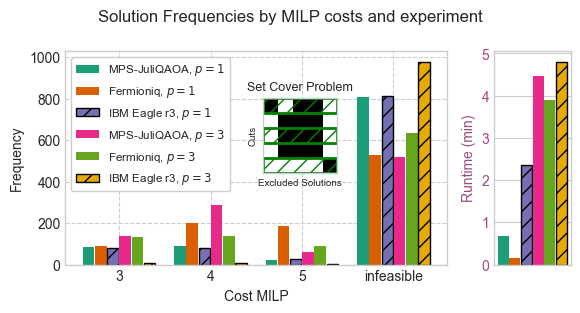

In [15]:
def plot_costs_by_experiment(
    experiments_results_df_costs,
    experiments,
    results,
    runtime_unit="h",
    plot_infeasible=True,
    plot_inset=False,
):
    # Prepare data for plotting
    experiment_labels = [exp["label"] for exp in experiments]
    frequency_cols = [f"frequency_{label}" for label in experiment_labels]

    # Group by cost_lp, summing frequencies for each experiment
    bars = {}
    for label, freq_col in zip(experiment_labels, frequency_cols):
        # Feasible solutions: group by cost_lp, sum frequencies
        feasible = experiments_results_df_costs["feasible"] == True
        cost_freq = (
            experiments_results_df_costs[feasible]
            .groupby("cost_lp")[freq_col]
            .sum()
            .sort_index()
        )
        # Infeasible solutions: sum all frequencies where feasible == False
        infeasible_freq = experiments_results_df_costs.loc[
            ~feasible, freq_col
        ].sum()
        new_label = re.sub(r"-(\d+)$", r", $p=\1$", label)
        new_label = re.sub(" QAOA", "", new_label)
        bars[new_label] = (cost_freq, infeasible_freq)

    # Plotting
    cm = 1 / 2.54  # centimeters in inches
    fig, axs = plt.subplots(
        figsize=(15 * cm, 8 * cm),
        ncols=2,
        gridspec_kw={"width_ratios": [5, 1]},
    )
    ax = axs[0]
    width = 0.8 / len(bars)
    x_vals = sorted(
        set(
            cost
            for cost_freq, _ in bars.values()
            for cost in cost_freq.index
            if pd.notnull(cost)
        )
    )
    if plot_infeasible:
        x_pos = np.arange(len(x_vals) + 1)
    else:
        x_pos = np.arange(len(x_vals))

    colors_local = cmap_dark2.colors
    highlight_color = "#9E4780"

    for i, (label, (cost_freq, infeasible_freq)) in enumerate(bars.items()):
        if plot_infeasible:
            y = [cost_freq.get(cost, 0) for cost in x_vals] + [infeasible_freq]
        else:
            y = [cost_freq.get(cost, 0) for cost in x_vals]
        ax.bar(
            x_pos + i * width - width * (len(bars) - 1) / 2,
            y,
            width=width * 0.95,
            label=label,
            color=[colors_local[i % len(colors_local)]] * len(y),
            hatch="//" if "IBM" in label else "",
            edgecolor="black" if "IBM" in label else None,
        )

    ax.grid(True, linestyle="--")
    ax.set_axisbelow(True)

    ax_runtime = axs[1]
    ax_runtime.set_ylabel(f"Runtime ({runtime_unit})", color=highlight_color)
    ax_runtime.tick_params(axis="y", labelcolor=highlight_color)

    match runtime_unit:
        case "h":
            runtime_divisor = 3600
        case "min":
            runtime_divisor = 60
        case "s":
            runtime_divisor = 1
        case _:
            raise ValueError(
                "Invalid runtime unit. Choose 'h', 'min', or 's'."
            )

    for i, label in enumerate(experiment_labels):
        match results[i][0]["backend-type"]:
            case "fermioniq":
                runtime = results[i][1][2].job_metadata["total_runtime"]
            case "qiskit":
                runtime = results[i][1][
                    2
                ].min_eigen_solver_result.optimizer_time
            case "mps-juliqaoa":
                runtime = results[i][1][2]["runtime"]
            case _:
                raise ValueError(
                    f"Unknown backend type: {results[i][0]['backend-type']}"
                )
        ax_runtime.bar(
            i * width - width * (len(bars) - 1) / 2,
            runtime / runtime_divisor,
            width=width * 0.95,
            label=label + " runtime",
            color=colors_local[i % len(colors_local)],
            hatch="//" if "IBM" in label else "",
            edgecolor="black" if "IBM" in label else None,
        )

    ax_runtime.grid(True)
    ax_runtime.set_xticks([])

    # X-axis labels
    ax.set_xticks(x_pos)
    if plot_infeasible:
        ax.set_xticklabels(
            [str(int(x)) for x in x_vals] + ["infeasible"], minor=False
        )
    else:
        ax.set_xticklabels([str(int(x)) for x in x_vals], minor=False)
    ax.set_xlabel("Cost MILP")
    ax.set_ylabel("Frequency")
    fig.suptitle("Solution Frequencies by MILP costs and experiment")
    ax.legend(
        loc="upper left",
        fontsize="small",
        frameon=True,
        framealpha=1,
        facecolor="white",
    )

    # Add set cover inset (optional, requires benchmarking results)
    # Disabled by default since it requires access to original benchmarking/results/raw/
    if plot_inset:
        # print("Warning: Set cover inset requires original benchmarking results.")
        # Uncomment below if you have the original data
        binary_indicator_matrix = get_binary_indicator_matrix(experiments[0])
        ax_inset = ax.inset_axes([0.44, 0.43, 0.35, 0.35])
        solution = np.array(
            [
                int(x)
                for x in experiments_results_df_costs.loc[
                    experiments_results_df_costs["cost_lp"]
                    == experiments_results_df_costs["cost_lp"].min()
                ].index[1]
            ]
        )
        plot_set_cover(binary_indicator_matrix, solution=solution, ax=ax_inset)

    plt.tight_layout()
    return fig


plot_costs_by_experiment(
    experiments_results_df_costs,
    experiments,
    results,
    runtime_unit="min",
    plot_infeasible=True,
    plot_inset=True,  # Set to True if you have original benchmarking data
)

fig_name = "solution_frequencies_by_cost.pdf"
print(f"Saving figure to {figures_dir / fig_name}")
plt.savefig(figures_dir / fig_name, dpi=300, bbox_inches="tight")
plt.savefig(
    figures_dir
    / "archive"
    / f"solution_frequencies_by_cost_{int(time.time())}.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Summary

All paper figures have been generated:
- **Figure 1**: `pulp_benders_gaps.pdf` - QOptLib optimality gaps
- **Figure 2**: `pulp_benders_times.pdf` - QOptLib solve times
- **Figure 3**: `julia_benders_toy_gaps.pdf` - Toy HQC-MCMS gaps with Julia QAOA
- **VRP Solution**: `toy_0_vrp_solution.pdf` - Example VRP solution visualization
- **Figure 4**: `solution_frequencies_by_cost.pdf` - QAOA solution frequencies (archived data)

Figures are saved to `notebooks/figures/` with archived copies in `notebooks/figures/archive/`.